Dataset Loaded Successfully

Top 10 Run Scorers
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


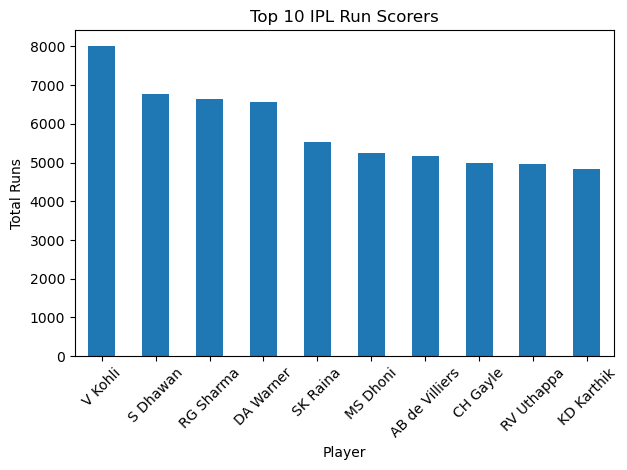


Top 10 Strike Rates
batter
L Wood             300.000000
B Stanlake         250.000000
J Fraser-McGurk    220.000000
R Sai Kishore      216.666667
Umar Gul           205.263158
RS Sodhi           200.000000
Shahid Afridi      176.086957
I Malhotra         175.000000
WG Jacks           172.932331
PD Salt            169.610390
dtype: float64


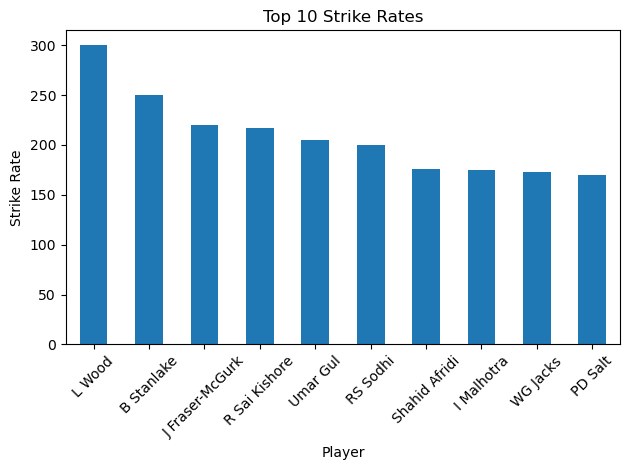

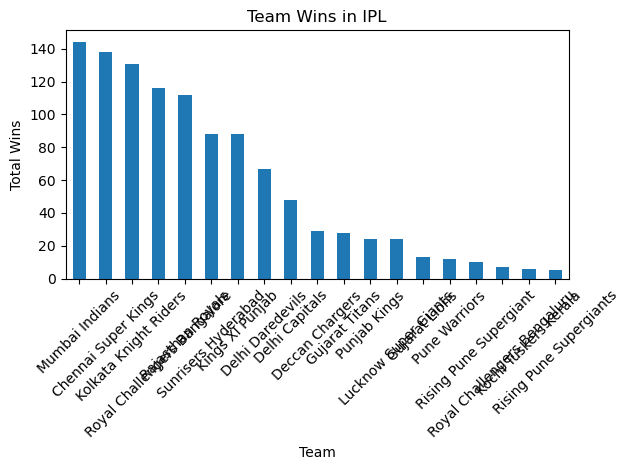


Runs Per Season
season
2007/08    16809
2009       15376
2009/10    17754
2011       19928
2012       21323
2013       21487
2014       17943
2015       17427
2016       17962
2017       17920
2018       19098
2019       18607
2020/21    18566
2021       17727
2022       23052
2023       24428
2024       24657
Name: batsman_runs, dtype: int64


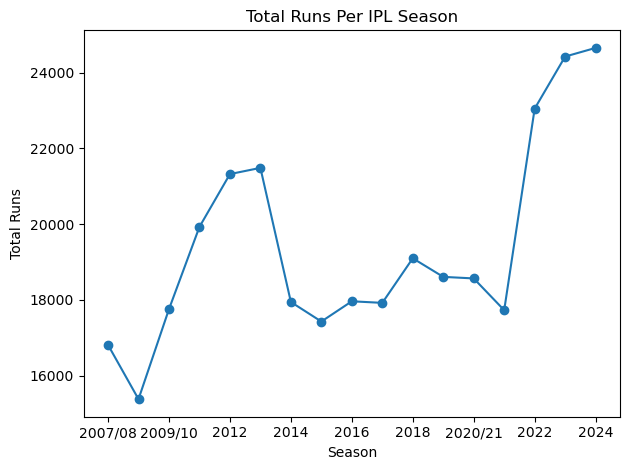


Virat Kohli Runs per Season
season
2007/08    165
2009       246
2009/10    307
2011       557
2012       364
2013       639
2014       359
2015       505
2016       973
2017       308
2018       530
2019       464
2020/21    471
2021       405
2022       341
2023       639
2024       741
Name: batsman_runs, dtype: int64


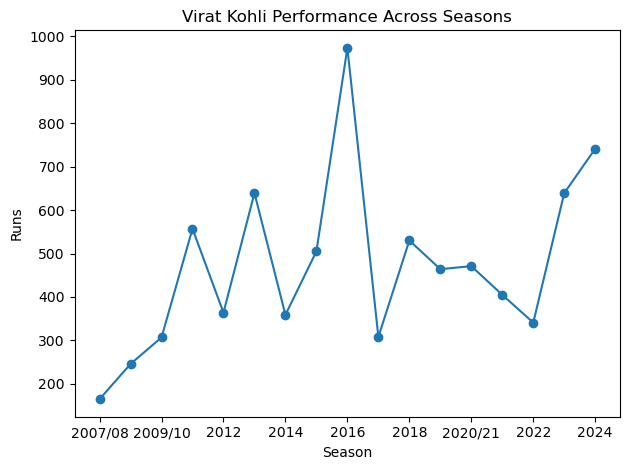


===== PROJECT INSIGHTS =====
Top Run Scorer: V Kohli
Most Successful Team: Mumbai Indians
Season With Highest Runs: 2024
Analysis Completed Successfully!


In [2]:

import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Dataset Loaded Successfully\n")

top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

print("Top 10 Run Scorers")
print(top_scorers)

plt.figure()
top_scorers.plot(kind='bar')

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


balls_faced = deliveries.groupby('batter')['ball'].count()
runs = deliveries.groupby('batter')['batsman_runs'].sum()

strike_rate = (runs / balls_faced) * 100

strike_rate = strike_rate.sort_values(ascending=False).head(10)

print("\nTop 10 Strike Rates")
print(strike_rate)

plt.figure()
strike_rate.plot(kind='bar')

plt.title("Top 10 Strike Rates")
plt.xlabel("Player")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


wins = matches['winner'].value_counts()

plt.figure()
wins.plot(kind='bar')

plt.title("Team Wins in IPL")
plt.xlabel("Team")
plt.ylabel("Total Wins")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')

season_total = season_runs.groupby('season')['batsman_runs'].sum()

print("\nRuns Per Season")
print(season_total)

plt.figure()
season_total.plot(kind='line', marker='o')

plt.title("Total Runs Per IPL Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")

plt.tight_layout()
plt.show()

player_data = season_runs[season_runs['batter'] == 'V Kohli']

kohli_runs = player_data.groupby('season')['batsman_runs'].sum()

print("\nVirat Kohli Runs per Season")
print(kohli_runs)

plt.figure()
kohli_runs.plot(kind='line', marker='o')

plt.title("Virat Kohli Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.tight_layout()
plt.show()


print("\n===== PROJECT INSIGHTS =====")

top_player = deliveries.groupby('batter')['batsman_runs'].sum().idxmax()
print("Top Run Scorer:", top_player)

best_team = matches['winner'].value_counts().idxmax()
print("Most Successful Team:", best_team)

best_season = season_total.idxmax()
print("Season With Highest Runs:", best_season)

print("Analysis Completed Successfully!")